# Machine Learning - Lab 06
## Model Evaluation, Cross-Validation and Generalization

| Section | Task |
|---|---|
| 1 | Class Task 1: Titanic survival prediction (classification) |
| 2 | Class Task 2: House price prediction (regression) |
| 3 | Lab Task 1: Metrics practice |
| 4 | Lab Task 2: Compare cross-validation strategies |
| 5 | Lab Task 3: Imbalanced classification |

**Files needed:** `titanic_train.csv` (Kaggle Titanic `train.csv`) and `house_train.csv` (Kaggle *House Prices: Advanced Regression Techniques* `train.csv`). Sections 3 to 5 use built-in scikit-learn data, so they need no files.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, RepeatedKFold, LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, mean_absolute_error, mean_squared_error, r2_score)

# 1. Class Task 1 - Classification: Titanic Survival Prediction

## 1.1 Load and explore the dataset

In [2]:
titanic = pd.read_csv("Titanic-Dataset.csv")
print(titanic.shape)
print(titanic.isnull().sum()[titanic.isnull().sum() > 0])
print()
print(titanic["Survived"].value_counts())
titanic.head()

(891, 12)
Age         177
Cabin       687
Embarked      2
dtype: int64

Survived
0    549
1    342
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1.2 Features, target and preprocessing
- **Target:** `Survived` (0 = no, 1 = yes). **Features:** everything useful that remains.
- Dropped: `PassengerId`, `Name`, `Ticket` (identifiers) and `Cabin` (mostly missing).
- Encoding: `Sex` -> 0/1, `Embarked` -> one-hot columns.
- Missing values (`Age`) are filled with the **median** by an imputer placed **inside the pipeline**. This way the median is learned from training data only, also inside every cross-validation fold (no data leakage).

In [3]:
data = titanic.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
data["Sex"] = data["Sex"].map({"male": 0, "female": 1})
data = pd.get_dummies(data, columns=["Embarked"], dtype=int)

X = data.drop(columns="Survived")
y = data["Survived"]
print(list(X.columns))

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


## 1.3 Split into 80% training and 20% testing
**Why keep the test data separate?** The test set imitates new, unseen passengers. If the model (or its settings) were influenced by test data, the score would be too optimistic and would not show how the model behaves in the real world. So the test set is used **only once, at the end**.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Training:", X_train.shape, " Testing:", X_test.shape)

Training: (712, 9)  Testing: (179, 9)


## 1.4 Train a Random Forest
**Parameters vs hyperparameters**
- **Hyperparameters** are chosen by us *before* training: `n_estimators` (number of trees), `max_depth` (tree depth), `min_samples_split` (minimum samples needed to split a node).
- **Parameters** are learned *automatically during training*: the split features and thresholds inside every tree, and the class votes stored in the leaves.

In [5]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("forest", RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_split=5, random_state=42)),
])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

## 1.5 Predict on the test set and evaluate

In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]          # probability of survival (needed for ROC-AUC)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion matrix:")
print(cm)
print()

test_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy   :", round(test_accuracy, 3))
print("Precision  :", round(precision_score(y_test, y_pred), 3))
print("Recall     :", round(recall_score(y_test, y_pred), 3))
print("F1-score   :", round(f1_score(y_test, y_pred), 3))
print("Specificity:", round(tn / (tn + fp), 3))
print("ROC-AUC    :", round(roc_auc_score(y_test, y_prob), 3))

Confusion matrix:
[[104   6]
 [ 27  42]]

Accuracy   : 0.816
Precision  : 0.875
Recall     : 0.609
F1-score   : 0.718
Specificity: 0.945
ROC-AUC    : 0.839


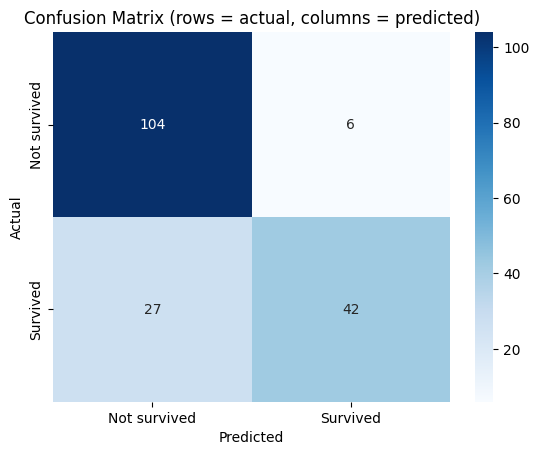

In [7]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not survived", "Survived"], yticklabels=["Not survived", "Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (rows = actual, columns = predicted)")
plt.show()

## 1.6 5-Fold and Stratified K-Fold cross-validation (on the training data only)

In [8]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

kf_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring="accuracy")
skf_scores = cross_val_score(model, X_train, y_train, cv=skfold, scoring="accuracy")

print("K-Fold            :", kf_scores.round(3), "| mean =", round(kf_scores.mean(), 3), "| std =", round(kf_scores.std(), 3))
print("Stratified K-Fold :", skf_scores.round(3), "| mean =", round(skf_scores.mean(), 3), "| std =", round(skf_scores.std(), 3))

K-Fold            : [0.79  0.811 0.81  0.831 0.866] | mean = 0.822 | std = 0.026
Stratified K-Fold : [0.839 0.783 0.859 0.796 0.796] | mean = 0.815 | std = 0.029


## 1.7 Compare cross-validation with the final test performance

In [9]:
comparison = pd.DataFrame({
    "Method": ["K-Fold CV (mean)", "Stratified K-Fold CV (mean)", "Final test set"],
    "Accuracy": [kf_scores.mean(), skf_scores.mean(), test_accuracy],
}).round(3)
print(comparison)

gap = abs(skf_scores.mean() - test_accuracy)
print()
print("Difference between CV mean and test accuracy:", round(gap, 3))
print("Std of the fold scores:", round(skf_scores.std(), 3))
if gap < 0.03 and skf_scores.std() < 0.03:
    print("Conclusion: the model performs CONSISTENTLY across different data splits.")
else:
    print("Conclusion: the results vary somewhat between splits, so the model is not perfectly consistent.")

                        Method  Accuracy
0             K-Fold CV (mean)     0.822
1  Stratified K-Fold CV (mean)     0.815
2               Final test set     0.816

Difference between CV mean and test accuracy: 0.001
Std of the fold scores: 0.029
Conclusion: the model performs CONSISTENTLY across different data splits.


**Conclusion**
- The mean cross-validation accuracy is close to the test accuracy when the model generalizes well. A small standard deviation means every fold gave a similar score, i.e. the performance does not depend on which passengers ended up in the training data.
- **Why is cross-validation useful in addition to one train/test split?** A single split can be lucky or unlucky: the score depends on which rows landed in the test set. Cross-validation evaluates the model on several different validation folds and reports a **mean** (expected performance) and a **standard deviation** (stability), which is a much more reliable estimate of generalization. It also lets us compare models and hyperparameters without touching the test set.
- Stratified K-Fold keeps the survived/not-survived ratio in every fold, so it is the preferred choice for classification.

# 2. Class Task 2 - Regression: House Price Prediction

## 2.1 Load and explore the dataset

In [11]:
house = pd.read_csv("train.csv")
print(house.shape)
print(house["SalePrice"].describe().round(0))
house[["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "1stFlrSF", "SalePrice"]].head()

(1460, 81)
count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,1stFlrSF,SalePrice
0,7,1710,2,856,856,208500
1,6,1262,2,1262,1262,181500
2,7,1786,2,920,920,223500
3,7,1717,3,756,961,140000
4,8,2198,3,1145,1145,250000


## 2.2 Select features and handle missing values
Features: `OverallQual`, `GrLivArea`, `GarageCars`, `TotalBsmtSF`, `1stFlrSF`. Target: `SalePrice`. Missing values are filled with the median by an imputer inside the pipeline (learned from training data only). These features are numeric, so no encoding is needed.

In [12]:
features = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "1stFlrSF"]
X = house[features]
y = house["SalePrice"]
print("Missing values per feature:")
print(X.isnull().sum())

Missing values per feature:
OverallQual    0
GrLivArea      0
GarageCars     0
TotalBsmtSF    0
1stFlrSF       0
dtype: int64


## 2.3 Split into 80% training and 20% testing
The test data must **not** be used during training because it represents houses the model has never seen. Using it to train or tune would leak information and make the final score unrealistically good.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training:", X_train.shape, " Testing:", X_test.shape)

Training: (1168, 5)  Testing: (292, 5)


## 2.4 Train a Random Forest Regressor
- **Hyperparameters** (set before training): `n_estimators`, `max_depth`, `min_samples_split`.
- **Parameters** (learned during training): the split rules in every tree and the average house price stored in each leaf.

In [14]:
reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("forest", RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42)),
])
reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

## 2.5 Predict on the test set and evaluate (MAE, MSE, RMSE, R2)

In [15]:
y_pred = reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
test_r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2  :", round(test_r2, 3))

MAE : 19773.58
MSE : 932732323.41
RMSE: 30540.67
R2  : 0.878


## 2.6 5-Fold cross-validation on the training data

In [16]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(reg, X_train, y_train, cv=kfold, scoring="r2")

for i, score in enumerate(cv_r2, start=1):
    print("Fold", i, "R2 =", round(score, 3))
print("Mean R2:", round(cv_r2.mean(), 3))
print("Std  R2:", round(cv_r2.std(), 3))

Fold 1 R2 = 0.84
Fold 2 R2 = 0.683
Fold 3 R2 = 0.797
Fold 4 R2 = 0.821
Fold 5 R2 = 0.806
Mean R2: 0.79
Std  R2: 0.055


## 2.7 Compare cross-validation with the test results

In [17]:
print("CV mean R2 :", round(cv_r2.mean(), 3))
print("Test R2    :", round(test_r2, 3))
print("Difference :", round(abs(cv_r2.mean() - test_r2), 3))
print()
if abs(cv_r2.mean() - test_r2) < 0.05 and cv_r2.std() < 0.05:
    print("The model performs consistently across folds and on the test set.")
else:
    print("The scores differ noticeably between folds / test set: the model is less consistent.")

CV mean R2 : 0.79
Test R2    : 0.878
Difference : 0.089

The scores differ noticeably between folds / test set: the model is less consistent.


**Discussion**
- If the R2 values of all five folds are close to each other (small standard deviation) and close to the test R2, the model performs **consistently** and is not depending on one lucky split.
- Cross-validation helps us understand the **generalization ability** of a regression model: every fold acts as a small test on data the model did not train on, so the mean R2 estimates how well it will predict *new* houses and the standard deviation shows how stable that estimate is. A large drop from training performance to CV performance, or very different fold scores, would signal overfitting or sensitivity to the data.
- R2 is the share of the variation in `SalePrice` explained by the model; RMSE and MAE are in price units (dollars), so they say how far off a typical prediction is.

# 3. Lab Task 1 - Metrics Practice
Binary dataset: scikit-learn's breast cancer data. We treat **malignant as the positive class (1)** and benign as 0.

In [18]:
cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = 1 - cancer.target                 # in the original data 0 = malignant, so flip: 1 = malignant
print("Class counts (0 = benign, 1 = malignant):")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Class counts (0 = benign, 1 = malignant):
target
0    357
1    212
Name: count, dtype: int64


**1. Train a classification model** (Logistic Regression with scaling) and **2. generate predictions**

In [19]:
clf = Pipeline([("scaler", StandardScaler()), ("logreg", LogisticRegression(max_iter=1000))])
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

**3. Confusion matrix, 4. metrics, 5. ROC-AUC**

In [20]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion matrix:")
print(cm)
print("TN =", tn, " FP =", fp, " FN =", fn, " TP =", tp)
print()
print("Accuracy   :", round(accuracy_score(y_test, y_pred), 3))
print("Precision  :", round(precision_score(y_test, y_pred), 3))
print("Recall     :", round(recall_score(y_test, y_pred), 3))
print("Specificity:", round(tn / (tn + fp), 3))
print("F1-score   :", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC    :", round(roc_auc_score(y_test, y_prob), 3))

Confusion matrix:
[[71  1]
 [ 3 39]]
TN = 71  FP = 1  FN = 3  TP = 39

Accuracy   : 0.965
Precision  : 0.975
Recall     : 0.929
Specificity: 0.986
F1-score   : 0.951
ROC-AUC    : 0.996


**6. Which metric is most appropriate and why?**
**Recall** (sensitivity) is the most appropriate metric. This is a medical screening problem: a *false negative* (a malignant tumour predicted as benign) means a sick patient is sent home untreated, which is far more harmful than a *false positive* (an extra check on a healthy patient). Recall tells us how many of the real malignant cases the model catches.
Accuracy is still informative here because the classes are only moderately imbalanced (about 37% malignant), but it hides *which* kind of error is made. Precision, F1 and ROC-AUC should be reported next to recall: precision shows how many alarms are false, and ROC-AUC shows how well the model separates the two classes over all thresholds.

# 4. Lab Task 2 - Compare Cross-Validation Strategies

Same model (Decision Tree) and same data (breast cancer, training part), different cross-validation strategies: K-Fold, Stratified K-Fold and Repeated K-Fold (5 folds x 3 repeats).

In [21]:
tree = DecisionTreeClassifier(random_state=42)

strategies = {
    "K-Fold": KFold(n_splits=5, shuffle=True, random_state=42),
    "Stratified K-Fold": StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    "Repeated K-Fold": RepeatedKFold(n_splits=5, n_repeats=3, random_state=42),
}

rows = []
for name, cv in strategies.items():
    s = cross_val_score(tree, X_train, y_train, cv=cv, scoring="accuracy")
    rows.append([name, len(s), s.mean(), s.std()])

pd.DataFrame(rows, columns=["Strategy", "Number of scores", "Mean accuracy", "Std"]).round(4)

,Strategy,Number of scores,Mean accuracy,Std
0,K-Fold,5,0.9385,0.0112
1,Stratified K-Fold,5,0.9231,0.0326
2,Repeated K-Fold,15,0.9297,0.0323


**Comparison:** the means are very similar, because all three estimate the same thing. Repeated K-Fold produces 15 scores instead of 5 (every split is repeated with different random partitions), so its mean is usually the most stable estimate. The standard deviation shows how much the score changes from fold to fold.

**Why is Stratified K-Fold generally preferred for classification?** Normal K-Fold splits at random, so one fold may contain too few examples of a rare class. Stratified K-Fold keeps (almost) the same class proportions in every fold. Every fold is therefore representative of the whole data, the scores are less noisy, and it is much safer when classes are imbalanced. (For regression use plain K-Fold, because there are no classes.)

**LOOCV on a small dataset.** Leave-One-Out uses one sample for validation and all others for training, repeated for every sample. We use a small dataset of 60 rows because LOOCV needs one model fit per row, which is expensive for large data.

In [22]:
X_small = X.sample(60, random_state=42)
y_small = y.loc[X_small.index]

loo_scores = cross_val_score(clf, X_small, y_small, cv=LeaveOneOut())
print("Number of evaluations:", len(loo_scores))
print("LOOCV mean accuracy  :", round(loo_scores.mean(), 3))

Number of evaluations: 60
LOOCV mean accuracy  : 0.967


# 5. Lab Task 3 - Imbalanced Classification

**13. Create an imbalanced binary dataset** (about 95% class 0, 5% class 1)

In [23]:
X_imb, y_imb = make_classification(n_samples=3000, n_features=10, n_informative=6, n_redundant=0,
                                   weights=[0.95, 0.05], class_sep=1.2, flip_y=0.01, random_state=42)
print(pd.Series(y_imb).value_counts())

X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb)

0    2838
1     162
Name: count, dtype: int64


**14-15. Train a baseline classifier and report accuracy, precision, recall and F1**

In [24]:
def report(name, model):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return {"Model": name,
            "Accuracy": accuracy_score(y_te, pred),
            "Precision": precision_score(y_te, pred, zero_division=0),
            "Recall": recall_score(y_te, pred),
            "F1": f1_score(y_te, pred, zero_division=0)}

baseline = report("Logistic Regression (baseline)", LogisticRegression(max_iter=1000))
always_zero = report("Always predict class 0", DummyClassifier(strategy="most_frequent"))
pd.DataFrame([baseline, always_zero]).round(3)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression (baseline),0.958,0.684,0.406,0.51
1,Always predict class 0,0.947,0.000,0.000,0.00


**16. Why accuracy alone can be misleading**
Only about 5% of the samples are positive, so a "model" that always predicts class 0 already gets about 95% accuracy while finding **none** of the positive cases (recall = 0). The accuracy of the real baseline model also looks high, but its recall is much lower than its accuracy, so it misses many positives. With rare classes (fraud, disease) we must look at precision, recall and F1.

**17-18. Try `class_weight='balanced'` and compare before and after**

In [25]:
balanced = report("Logistic Regression (class_weight='balanced')", LogisticRegression(max_iter=1000, class_weight="balanced"))
pd.DataFrame([baseline, balanced]).round(3)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression (baseline),0.958,0.684,0.406,0.510
1,Logistic Regression (class_weight='balanced'),0.872,0.273,0.844,0.412


**Comparison:** `class_weight="balanced"` makes mistakes on the rare class cost more during training. Compared with the baseline, **recall goes up** (more positive cases are found), **precision usually goes down** (more false alarms), and overall **accuracy can drop**. F1 shows the net effect. This trade-off is acceptable when missing a positive case is more costly than a false alarm.